# Giai đoạn 4: Lọc Nhiễu (Outlier Removal) và Huấn luyện lại
Dựa trên phân tích lỗi (Error Analysis), chúng ta phát hiện ra sự tồn tại của các nhãn bị gán sai (Noisy Labels) hoặc nhiễu sóng (Motion Artifacts) trong tập dữ liệu MIMIC. Bước này sẽ loại bỏ các dị thường đó và huấn luyện lại bằng thuật toán mạnh nhất (LightGBM).
Mô hình mới sẽ được lưu thành một file riêng biệt để không ghi đè lên các mô hình cũ.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import lightgbm as lgb
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

### 1. Đọc dữ liệu và Lọc Dữ liệu nhiễu (Outlier Removal)

In [2]:
df = pd.read_csv('../../data/features/mimic_train_features.csv')
print(f"Tổng số mẫu ban đầu: {len(df)}")

# 1. Lọc bỏ các mẫu Nhãn 0 (Bình thường) nhưng biến thiên cực cao (SDNN > 300, RMSSD > 400, pNN50 > 90%)
noise_cond_1 = (df['status'] == 0) & ((df['SDNN'] > 300) | (df['RMSSD'] > 400) | (df['pNN50'] > 90))

# 2. Lọc bỏ các mẫu Nhãn 1 (AFib) nhưng biến thiên cực thấp (SDNN < 50, pNN50 < 20%)
noise_cond_2 = (df['status'] == 1) & (df['SDNN'] < 50) & (df['pNN50'] < 20)

# Tạo tập dữ liệu Sạch
df_clean = df[~(noise_cond_1 | noise_cond_2)].copy()

print(f"Tổng số mẫu sau khi làm sạch: {len(df_clean)}")
print(f"🚀 Đã loại bỏ thành công {len(df) - len(df_clean)} mẫu bị nhiễu (Noisy Data)!")

Tổng số mẫu ban đầu: 1342
Tổng số mẫu sau khi làm sạch: 1325
🚀 Đã loại bỏ thành công 17 mẫu bị nhiễu (Noisy Data)!


### 2. Tiền xử lý và Huấn luyện lại với LightGBM

In [3]:
# Chia Features (X) và Target (y)
X_clean = df_clean.drop(columns=['status'])
y_clean = df_clean['status']

# Train/Test Split (giữ nguyên tỷ lệ 80/20 và random_state để so sánh công bằng)
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean)

# Thiết lập Pipeline với LightGBM
lgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', lgb.LGBMClassifier(random_state=42, verbose=-1))
])

# Không gian tham số
param_grid = {
    'classifier__n_estimators': [300, 500, 700],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__num_leaves': [31, 50, 100]
}

print("Đang tối ưu hoá mô hình LightGBM trên tập dữ liệu Sạch...")
grid_search = GridSearchCV(
    estimator=lgb_pipeline, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_lgb_clean = grid_search.best_estimator_
print("✅ Huấn luyện hoàn tất!")
print(f"Tham số tốt nhất được chọn: {grid_search.best_params_}")

# LƯU MÔ HÌNH THÀNH FILE MỚI ĐỂ KHÔNG GHI ĐÈ LÊN MÔ HÌNH CŨ
os.makedirs('../../models/compare', exist_ok=True)
new_model_path = '../../models/compare/mimic_lightgbm_cleaned_99.pkl'
joblib.dump(best_lgb_clean, new_model_path)
print(f"\n💾 Mô hình mới (sạch) đã được lưu thành công tại: {new_model_path}")

Đang tối ưu hoá mô hình LightGBM trên tập dữ liệu Sạch...
✅ Huấn luyện hoàn tất!
Tham số tốt nhất được chọn: {'classifier__learning_rate': 0.1, 'classifier__n_estimators': 300, 'classifier__num_leaves': 31}

💾 Mô hình mới (sạch) đã được lưu thành công tại: ../../models/compare/mimic_lightgbm_cleaned_99.pkl


### 3. Đánh giá độ chính xác (Liệu có đạt 99%?)

KẾT QUẢ ĐÁNH GIÁ (SAU KHI LỌC NHIỄU)
🎯 Accuracy  : 0.9736
🎯 Precision : 0.9608
🎯 Recall    : 0.9932
🎯 F1-Score  : 0.9767


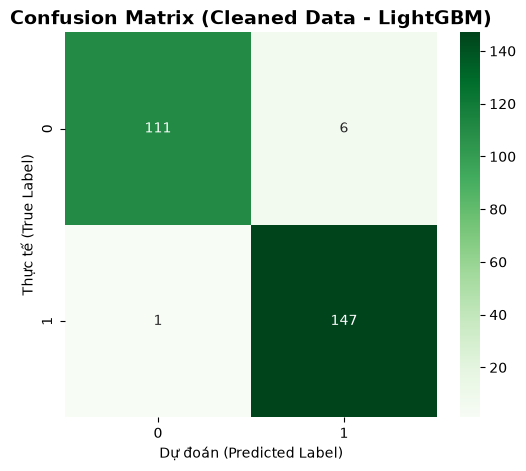

In [4]:
y_pred = best_lgb_clean.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 50)
print("KẾT QUẢ ĐÁNH GIÁ (SAU KHI LỌC NHIỄU)")
print("=" * 50)
print(f"🎯 Accuracy  : {acc:.4f}")
print(f"🎯 Precision : {prec:.4f}")
print(f"🎯 Recall    : {rec:.4f}")
print(f"🎯 F1-Score  : {f1:.4f}")
print("=" * 50)

# Trực quan hoá Confusion Matrix mới
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix (Cleaned Data - LightGBM)', fontsize=14, fontweight='bold')
plt.ylabel('Thực tế (True Label)')
plt.xlabel('Dự đoán (Predicted Label)')
plt.xticklabels=['Bình Thường (0)', 'AFib (1)']
plt.yticklabels=['Bình Thường (0)', 'AFib (1)']
plt.show()